# DITR Model Testing & Evaluation

This notebook evaluates our trained optical and geometric diffusion models on the ClearGrasp real-world test dataset.

**Test Protocol:**
- Dataset: ClearGrasp Real-World (d415/d435 cameras)
- Input: Transparent depth images (corrupted by glass/mirrors)
- Ground Truth: Opaque depth images (painted objects to get true depth)
- Resolution: 128x128 (matching training)

**Metrics (per DITR paper):**
- RMSE (Root Mean Square Error)
- MAE (Mean Absolute Error)  
- REL (Mean Relative Error)
- δ1.05, δ1.10, δ1.25 (Threshold Accuracy)

**Workflow:**
1. Visualize test data samples (RGB, mask, transparent/opaque depth)
2. Generate guidance maps (M_DA, M_RGB) for test images
3. Run DITR inference (optical + geometric branches → merge)
4. Compare predictions with ground truth
5. Compute metrics across the test set

In [1]:
# Cell 1: Imports and Configuration
import os
import glob
import random
import numpy as np
import torch
import cv2
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional

# Enable OpenEXR support
os.environ["OPENCV_IO_ENABLE_OPENEXR"] = "1"

# Import our modules
from diffusion import GaussianDiffusion, DiffusionConfig
from conditional_unet_depth import ConditionalUNetDepth
from guidance_maps import GuidanceConfig, m_da, m_rgb

# Configuration
@dataclass
class TestConfig:
    # Test dataset paths
    test_root: str = "/home/cago/MMI_714_generative_models/term_project/dataset/real-test/d435"
    val_root: str = "/home/cago/MMI_714_generative_models/term_project/dataset/real-val/d435"

    # Model paths
    model_dir: str = "/home/cago/MMI_714_generative_models/term_project/src"
    optical_model: str = "model_optical.pt"
    geometric_model: str = "model_geometric.pt"

    # Image size (must match training)
    img_size: Tuple[int, int] = (128, 128)

    # Depth normalization range (meters)
    depth_minmax: Tuple[float, float] = (0.0, 5.0)

    # Diffusion timesteps (must match training)
    timesteps: int = 1000

    # Device
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

cfg = TestConfig()
gcfg = GuidanceConfig(edge_detector='canny')  # Use Canny for guidance maps

print(f"Device: {cfg.device}")
print(f"Test dataset: {cfg.test_root}")
print(f"Validation dataset: {cfg.val_root}")

Device: cuda
Test dataset: /home/cago/MMI_714_generative_models/term_project/dataset/real-test/d435
Validation dataset: /home/cago/MMI_714_generative_models/term_project/dataset/real-val/d435


In [2]:
# Cell 2: Test Dataset Loader

class ClearGraspTestDataset:
    """
    Loads ClearGrasp real-world test/validation data.

    Each sample contains:
    - RGB image (transparent object visible)
    - Mask (1 = transparent area)
    - Transparent depth (corrupted by glass)
    - Opaque depth (ground truth - painted objects)
    """

    def __init__(self, root: str, cfg: TestConfig):
        self.root = root
        self.cfg = cfg

        # Find all sample IDs
        mask_files = sorted(glob.glob(os.path.join(root, "*-mask.png")))
        self.sample_ids = [os.path.basename(f).replace("-mask.png", "") for f in mask_files]

        print(f"Found {len(self.sample_ids)} samples in {root}")

    def __len__(self):
        return len(self.sample_ids)

    def _read_rgb(self, path: str) -> np.ndarray:
        """Read RGB image as BGR."""
        img = cv2.imread(path, cv2.IMREAD_COLOR)
        if img is None:
            raise FileNotFoundError(f"RGB not found: {path}")
        return cv2.resize(img, self.cfg.img_size, interpolation=cv2.INTER_AREA)

    def _read_depth(self, path: str) -> np.ndarray:
        """Read depth from EXR file."""
        depth = cv2.imread(path, cv2.IMREAD_UNCHANGED)
        if depth is None:
            raise FileNotFoundError(f"Depth not found: {path}")
        if depth.ndim == 3:
            depth = depth[..., 0]
        depth = cv2.resize(depth, self.cfg.img_size, interpolation=cv2.INTER_NEAREST)
        depth = np.nan_to_num(depth.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
        return depth

    def _read_mask(self, path: str) -> np.ndarray:
        """Read binary mask (1 = transparent area)."""
        mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise FileNotFoundError(f"Mask not found: {path}")
        mask = cv2.resize(mask, self.cfg.img_size, interpolation=cv2.INTER_NEAREST)
        return (mask > 127).astype(np.float32)

    def _norm_depth(self, depth: np.ndarray) -> np.ndarray:
        """Normalize depth to [-1, 1]."""
        dmin, dmax = self.cfg.depth_minmax
        d = np.clip(depth, dmin, dmax)
        d = (d - dmin) / max(dmax - dmin, 1e-6)  # [0, 1]
        d = d * 2.0 - 1.0  # [-1, 1]
        return d.astype(np.float32)

    def _denorm_depth(self, depth_norm: np.ndarray) -> np.ndarray:
        """Denormalize depth from [-1, 1] to meters."""
        dmin, dmax = self.cfg.depth_minmax
        d = (depth_norm + 1.0) / 2.0  # [0, 1]
        return d * (dmax - dmin) + dmin

    def __getitem__(self, idx: int) -> Dict:
        sid = self.sample_ids[idx]

        # Build file paths
        rgb_path = os.path.join(self.root, f"{sid}-transparent-rgb-img.jpg")
        mask_path = os.path.join(self.root, f"{sid}-mask.png")
        trans_depth_path = os.path.join(self.root, f"{sid}-transparent-depth-img.exr")
        opaque_depth_path = os.path.join(self.root, f"{sid}-opaque-depth-img.exr")

        # Load data
        rgb = self._read_rgb(rgb_path)
        mask = self._read_mask(mask_path)
        trans_depth = self._read_depth(trans_depth_path)
        opaque_depth = self._read_depth(opaque_depth_path)

        # Normalize depths
        trans_depth_norm = self._norm_depth(trans_depth)
        opaque_depth_norm = self._norm_depth(opaque_depth)

        return {
            "sample_id": sid,
            "rgb": rgb,                          # (H, W, 3) BGR uint8
            "mask": mask,                        # (H, W) float32, 1=transparent
            "trans_depth": trans_depth,          # (H, W) meters
            "opaque_depth": opaque_depth,        # (H, W) meters (ground truth)
            "trans_depth_norm": trans_depth_norm,   # (H, W) [-1, 1]
            "opaque_depth_norm": opaque_depth_norm, # (H, W) [-1, 1]
        }

# Load test and validation datasets
test_dataset = ClearGraspTestDataset(cfg.test_root, cfg)
val_dataset = ClearGraspTestDataset(cfg.val_root, cfg)

print(f"\nTest samples: {len(test_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Found 23 samples in /home/cago/MMI_714_generative_models/term_project/dataset/real-test/d435
Found 173 samples in /home/cago/MMI_714_generative_models/term_project/dataset/real-val/d435

Test samples: 23
Validation samples: 173


## 1. Visualize Test Data Sample

Let's look at a random sample from the test set to understand the data structure.

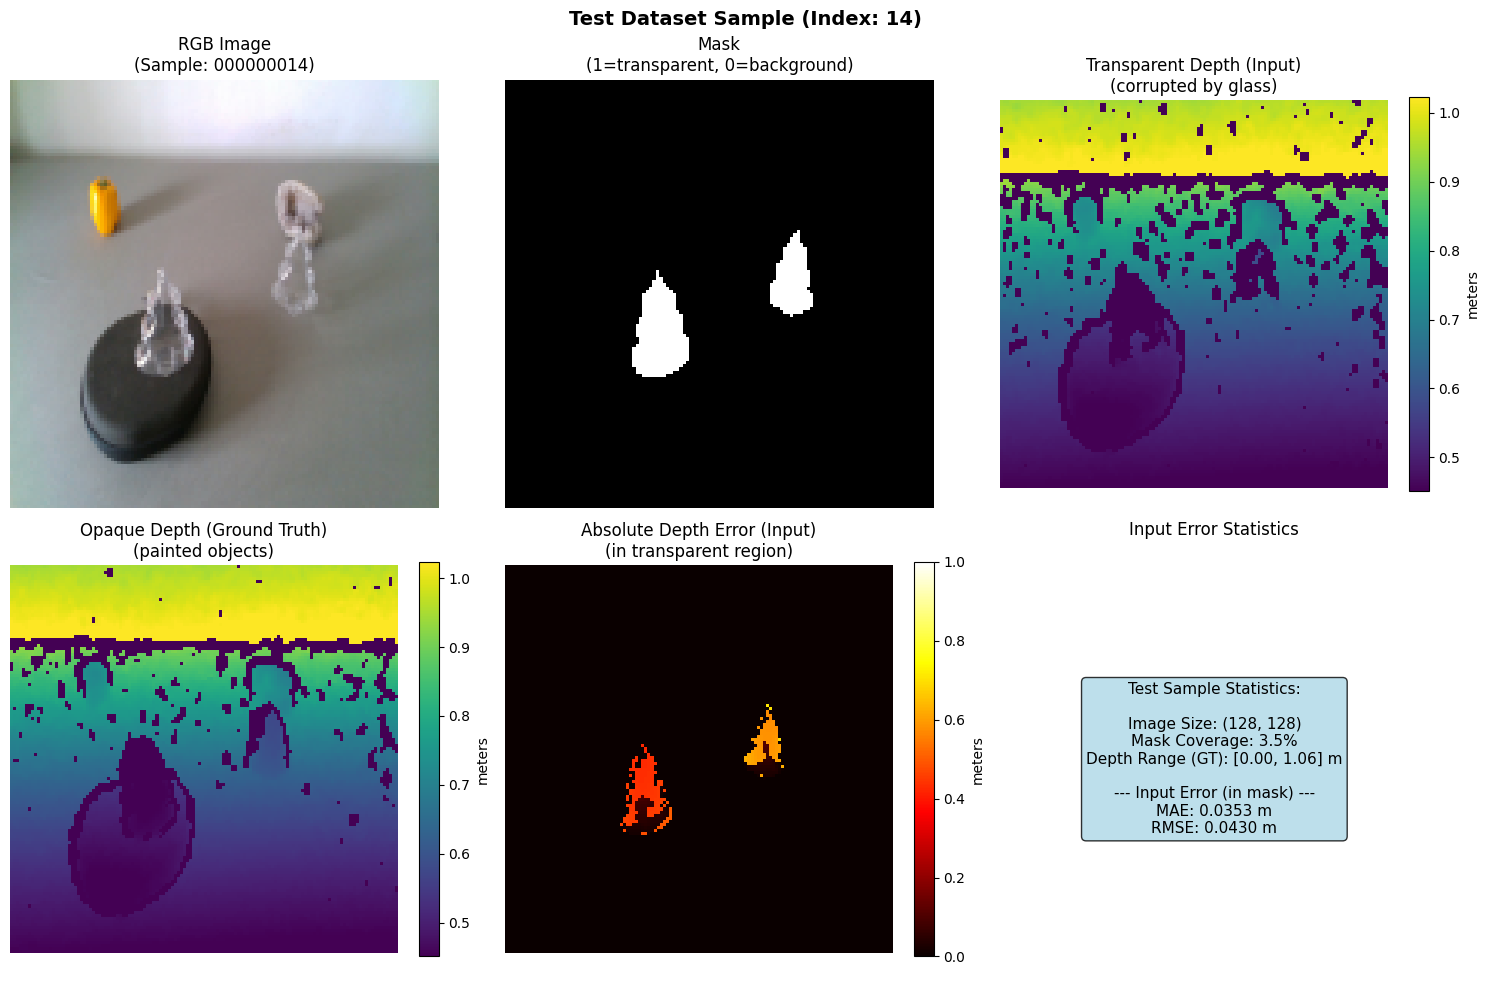

In [3]:
# Cell 3: Visualize a random test sample

def visualize_test_sample(sample: Dict, title: str = "Test Sample"):
    """Visualize RGB, mask, transparent depth, and opaque depth (ground truth)."""

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # RGB
    rgb_vis = cv2.cvtColor(sample["rgb"], cv2.COLOR_BGR2RGB)
    axes[0, 0].imshow(rgb_vis)
    axes[0, 0].set_title(f"RGB Image\n(Sample: {sample['sample_id']})")
    axes[0, 0].axis('off')

    # Mask
    axes[0, 1].imshow(sample["mask"], cmap='gray', vmin=0, vmax=1)
    axes[0, 1].set_title("Mask\n(1=transparent, 0=background)")
    axes[0, 1].axis('off')

    # Transparent depth (corrupted input)
    vmin = np.percentile(sample["opaque_depth"][sample["opaque_depth"] > 0.01], 5) if (sample["opaque_depth"] > 0.01).any() else 0
    vmax = np.percentile(sample["opaque_depth"][sample["opaque_depth"] > 0.01], 95) if (sample["opaque_depth"] > 0.01).any() else 5

    im = axes[0, 2].imshow(sample["trans_depth"], cmap='viridis', vmin=vmin, vmax=vmax)
    axes[0, 2].set_title("Transparent Depth (Input)\n(corrupted by glass)")
    axes[0, 2].axis('off')
    plt.colorbar(im, ax=axes[0, 2], fraction=0.046, label='meters')

    # Opaque depth (ground truth)
    im = axes[1, 0].imshow(sample["opaque_depth"], cmap='viridis', vmin=vmin, vmax=vmax)
    axes[1, 0].set_title("Opaque Depth (Ground Truth)\n(painted objects)")
    axes[1, 0].axis('off')
    plt.colorbar(im, ax=axes[1, 0], fraction=0.046, label='meters')

    # Depth difference
    diff = np.abs(sample["opaque_depth"] - sample["trans_depth"])
    diff_masked = diff * sample["mask"]  # Only show difference in transparent region
    im = axes[1, 1].imshow(diff_masked, cmap='hot', vmin=0, vmax=1.0)
    axes[1, 1].set_title("Absolute Depth Error (Input)\n(in transparent region)")
    axes[1, 1].axis('off')
    plt.colorbar(im, ax=axes[1, 1], fraction=0.046, label='meters')

    # Depth statistics
    mask_bool = sample["mask"] > 0.5
    if mask_bool.any():
        trans_in_mask = sample["trans_depth"][mask_bool]
        opaque_in_mask = sample["opaque_depth"][mask_bool]
        valid = (opaque_in_mask > 0.01) & (trans_in_mask > 0.01)
        if valid.any():
            mae = np.abs(opaque_in_mask[valid] - trans_in_mask[valid]).mean()
            rmse = np.sqrt(((opaque_in_mask[valid] - trans_in_mask[valid])**2).mean())
        else:
            mae = rmse = float('nan')
    else:
        mae = rmse = float('nan')

    axes[1, 2].text(0.5, 0.5,
        f"Test Sample Statistics:\n\n"
        f"Image Size: {sample['rgb'].shape[:2]}\n"
        f"Mask Coverage: {sample['mask'].mean()*100:.1f}%\n"
        f"Depth Range (GT): [{sample['opaque_depth'].min():.2f}, {sample['opaque_depth'].max():.2f}] m\n\n"
        f"--- Input Error (in mask) ---\n"
        f"MAE: {mae:.4f} m\n"
        f"RMSE: {rmse:.4f} m",
        ha='center', va='center', fontsize=11,
        transform=axes[1, 2].transAxes,
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    axes[1, 2].axis('off')
    axes[1, 2].set_title("Input Error Statistics")

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Visualize a random sample
random_idx = random.randint(0, len(test_dataset) - 1)
sample = test_dataset[random_idx]
visualize_test_sample(sample, f"Test Dataset Sample (Index: {random_idx})")

## 2. Generate Guidance Maps (M_DA and M_RGB)

The DITR pipeline uses two types of guidance maps:
- **M_DA (Depth-Aware)**: For optical branch - intersection of RGB and depth edges
- **M_RGB**: For geometric branch - RGB edges only (in background region)

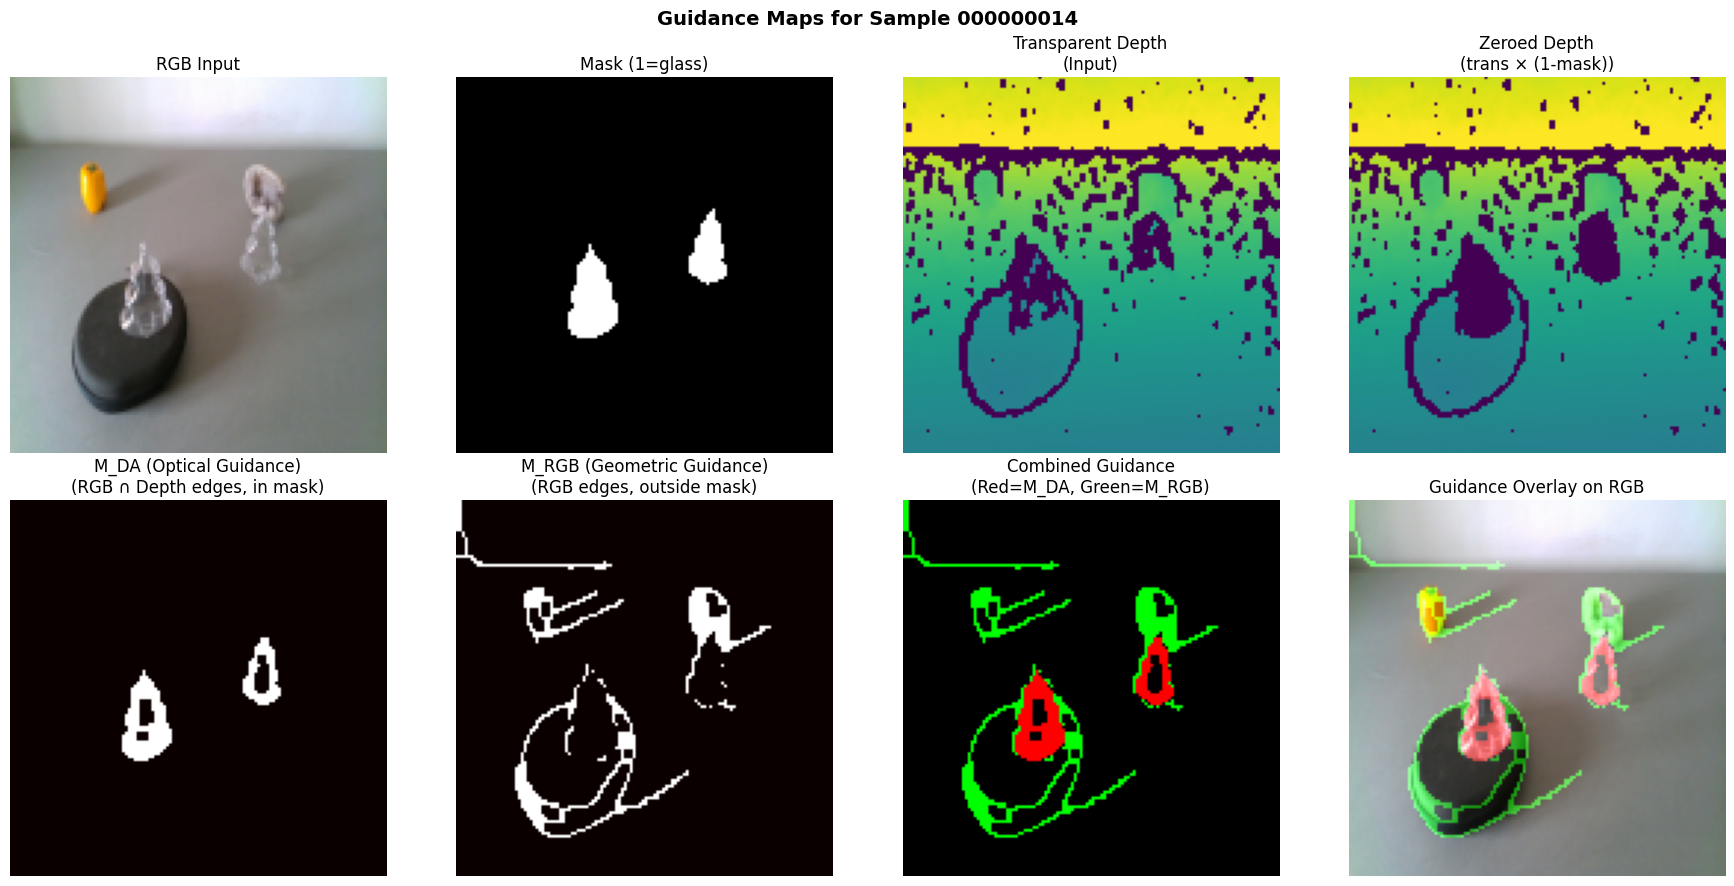

In [4]:
# Cell 4: Generate and visualize guidance maps for the sample

def generate_guidance_maps(sample: Dict, gcfg: GuidanceConfig) -> Dict:
    """
    Generate M_DA (optical) and M_RGB (geometric) guidance maps.

    Args:
        sample: Dictionary from ClearGraspTestDataset
        gcfg: GuidanceConfig

    Returns:
        Dictionary with guidance maps
    """
    rgb = sample["rgb"]  # BGR format
    mask = sample["mask"]
    trans_depth = sample["trans_depth"]

    # For M_DA: use depth with transparent region zeroed out
    # This simulates what the depth sensor "sees through" the glass
    zeroed_depth = trans_depth * (1.0 - mask)

    # Generate M_DA (Optical): intersection of RGB and depth edges, masked to transparent region
    mda = m_da(rgb, trans_depth, gcfg, mask=mask, zeroed_depth=zeroed_depth)

    # Generate M_RGB (Geometric): RGB edges, masked to background region
    mrgb = m_rgb(rgb, gcfg, mask=mask)

    return {
        "m_da": mda,      # Guidance for optical branch (inside mask)
        "m_rgb": mrgb,    # Guidance for geometric branch (outside mask)
        "zeroed_depth": zeroed_depth,
    }


def visualize_guidance_maps(sample: Dict, guidance: Dict, title: str = "Guidance Maps"):
    """Visualize the guidance maps alongside the input data."""

    fig, axes = plt.subplots(2, 4, figsize=(18, 9))

    # Row 1: Input data
    rgb_vis = cv2.cvtColor(sample["rgb"], cv2.COLOR_BGR2RGB)
    axes[0, 0].imshow(rgb_vis)
    axes[0, 0].set_title("RGB Input")
    axes[0, 0].axis('off')

    axes[0, 1].imshow(sample["mask"], cmap='gray', vmin=0, vmax=1)
    axes[0, 1].set_title("Mask (1=glass)")
    axes[0, 1].axis('off')

    vmin = 0
    vmax = np.percentile(sample["trans_depth"][sample["trans_depth"] > 0.01], 95) if (sample["trans_depth"] > 0.01).any() else 5
    axes[0, 2].imshow(sample["trans_depth"], cmap='viridis', vmin=vmin, vmax=vmax)
    axes[0, 2].set_title("Transparent Depth\n(Input)")
    axes[0, 2].axis('off')

    axes[0, 3].imshow(guidance["zeroed_depth"], cmap='viridis', vmin=vmin, vmax=vmax)
    axes[0, 3].set_title("Zeroed Depth\n(trans × (1-mask))")
    axes[0, 3].axis('off')

    # Row 2: Guidance maps
    axes[1, 0].imshow(guidance["m_da"], cmap='hot', vmin=0, vmax=1)
    axes[1, 0].set_title("M_DA (Optical Guidance)\n(RGB ∩ Depth edges, in mask)")
    axes[1, 0].axis('off')

    axes[1, 1].imshow(guidance["m_rgb"], cmap='hot', vmin=0, vmax=1)
    axes[1, 1].set_title("M_RGB (Geometric Guidance)\n(RGB edges, outside mask)")
    axes[1, 1].axis('off')

    # Combined visualization
    combined = np.zeros((*sample["mask"].shape, 3), dtype=np.float32)
    combined[..., 0] = guidance["m_da"]  # Red = optical (inside mask)
    combined[..., 1] = guidance["m_rgb"]  # Green = geometric (outside mask)
    axes[1, 2].imshow(combined)
    axes[1, 2].set_title("Combined Guidance\n(Red=M_DA, Green=M_RGB)")
    axes[1, 2].axis('off')

    # Overlay on RGB
    overlay = rgb_vis.astype(np.float32) / 255.0
    overlay[..., 0] = np.clip(overlay[..., 0] + guidance["m_da"] * 0.5, 0, 1)
    overlay[..., 1] = np.clip(overlay[..., 1] + guidance["m_rgb"] * 0.5, 0, 1)
    axes[1, 3].imshow(overlay)
    axes[1, 3].set_title("Guidance Overlay on RGB")
    axes[1, 3].axis('off')

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Generate guidance maps for the sample
guidance = generate_guidance_maps(sample, gcfg)
visualize_guidance_maps(sample, guidance, f"Guidance Maps for Sample {sample['sample_id']}")

## 3. Load Trained Models

Load the trained optical and geometric diffusion models.

In [5]:
# Cell 5: Load trained models

def load_models(cfg: TestConfig):
    """Load trained optical and geometric diffusion models."""
    device = torch.device(cfg.device)

    # Optical model
    opt_model_path = os.path.join(cfg.model_dir, cfg.optical_model)
    opt_model = ConditionalUNetDepth(cond_channels=5).to(device)
    opt_model.load_state_dict(torch.load(opt_model_path, map_location=device, weights_only=True))
    opt_diff = GaussianDiffusion(model=opt_model, config=DiffusionConfig(timesteps=cfg.timesteps)).to(device)
    opt_model.eval()
    print(f"✓ Loaded optical model from {opt_model_path}")

    # Geometric model
    geo_model_path = os.path.join(cfg.model_dir, cfg.geometric_model)
    geo_model = ConditionalUNetDepth(cond_channels=5).to(device)
    geo_model.load_state_dict(torch.load(geo_model_path, map_location=device, weights_only=True))
    geo_diff = GaussianDiffusion(model=geo_model, config=DiffusionConfig(timesteps=cfg.timesteps)).to(device)
    geo_model.eval()
    print(f"✓ Loaded geometric model from {geo_model_path}")

    return opt_diff, geo_diff, device

opt_diff, geo_diff, device = load_models(cfg)

✓ Loaded optical model from /home/cago/MMI_714_generative_models/term_project/src/model_optical.pt
✓ Loaded geometric model from /home/cago/MMI_714_generative_models/term_project/src/model_geometric.pt


## 4. DITR Inference Pipeline

Run the full DITR inference:
1. **Optical Branch**: Inpaints glass/transparent region using M_DA guidance
2. **Geometric Branch**: Refines background region using M_RGB guidance  
3. **Merge**: Combine outputs using the mask

In [6]:
# Cell 6: DITR Inference Function

def prepare_conditioning(sample: Dict, guidance: Dict, branch: str, cfg: TestConfig) -> torch.Tensor:
    """
    Prepare conditioning tensor for a branch.

    Conditioning layout: [RGB(3), raw_depth(1), guidance(1)] = 5 channels

    Args:
        sample: Test sample dictionary
        guidance: Guidance maps dictionary
        branch: 'optical' or 'geometric'
        cfg: Test configuration

    Returns:
        Conditioning tensor (1, 5, H, W)
    """
    rgb = sample["rgb"]  # BGR format
    mask = sample["mask"]
    trans_depth_norm = sample["trans_depth_norm"]

    # Raw depth with transparent region zeroed (simulating sensor failure)
    raw_depth = trans_depth_norm * (1.0 - mask)

    # Select guidance map based on branch
    if branch == "optical":
        guide = guidance["m_da"]
    else:  # geometric
        guide = guidance["m_rgb"]

    # Convert to tensors
    rgb_t = torch.from_numpy(rgb[:, :, ::-1].copy()).float() / 255.0  # BGR -> RGB, [0,1]
    rgb_t = rgb_t.permute(2, 0, 1)  # (3, H, W)

    raw_depth_t = torch.from_numpy(raw_depth).float().unsqueeze(0)  # (1, H, W)
    guide_t = torch.from_numpy(guide).float().unsqueeze(0)  # (1, H, W)

    # Concatenate: [RGB(3), raw_depth(1), guidance(1)]
    cond = torch.cat([rgb_t, raw_depth_t, guide_t], dim=0)  # (5, H, W)

    return cond.unsqueeze(0)  # (1, 5, H, W)


def run_ditr_inference(sample: Dict, guidance: Dict, opt_diff, geo_diff,
                       cfg: TestConfig, device: torch.device) -> Dict:
    """
    Run full DITR inference pipeline.

    Args:
        sample: Test sample dictionary
        guidance: Guidance maps dictionary
        opt_diff: Optical diffusion model
        geo_diff: Geometric diffusion model
        cfg: Test configuration
        device: Torch device

    Returns:
        Dictionary with predictions and intermediate results
    """
    opt_diff.model.eval()
    geo_diff.model.eval()

    # Prepare conditioning for each branch
    cond_opt = prepare_conditioning(sample, guidance, "optical", cfg).to(device)
    cond_geo = prepare_conditioning(sample, guidance, "geometric", cfg).to(device)

    # Mask tensor
    mask = torch.from_numpy(sample["mask"]).float().unsqueeze(0).unsqueeze(0).to(device)  # (1, 1, H, W)

    # Shape for sampling
    h, w = cfg.img_size
    shape = (1, 1, h, w)

    with torch.no_grad():
        # Run optical branch (inpaints glass region)
        pred_opt = opt_diff.sample(cond=cond_opt, shape=shape, device=device)

        # Run geometric branch (refines background)
        pred_geo = geo_diff.sample(cond=cond_geo, shape=shape, device=device)

    # Merge: optical inside mask, geometric outside mask
    merged = pred_opt * mask + pred_geo * (1.0 - mask)

    return {
        "pred_opt": pred_opt.cpu().numpy()[0, 0],      # (H, W) normalized
        "pred_geo": pred_geo.cpu().numpy()[0, 0],      # (H, W) normalized
        "merged": merged.cpu().numpy()[0, 0],           # (H, W) normalized
        "mask": mask.cpu().numpy()[0, 0],               # (H, W)
    }


def denorm_depth(depth_norm: np.ndarray, cfg: TestConfig) -> np.ndarray:
    """Denormalize depth from [-1, 1] to meters."""
    dmin, dmax = cfg.depth_minmax
    d = (depth_norm + 1.0) / 2.0  # [0, 1]
    return d * (dmax - dmin) + dmin

print("DITR inference functions defined.")

DITR inference functions defined.


Running DITR inference (this may take a minute for 1000 diffusion steps)...


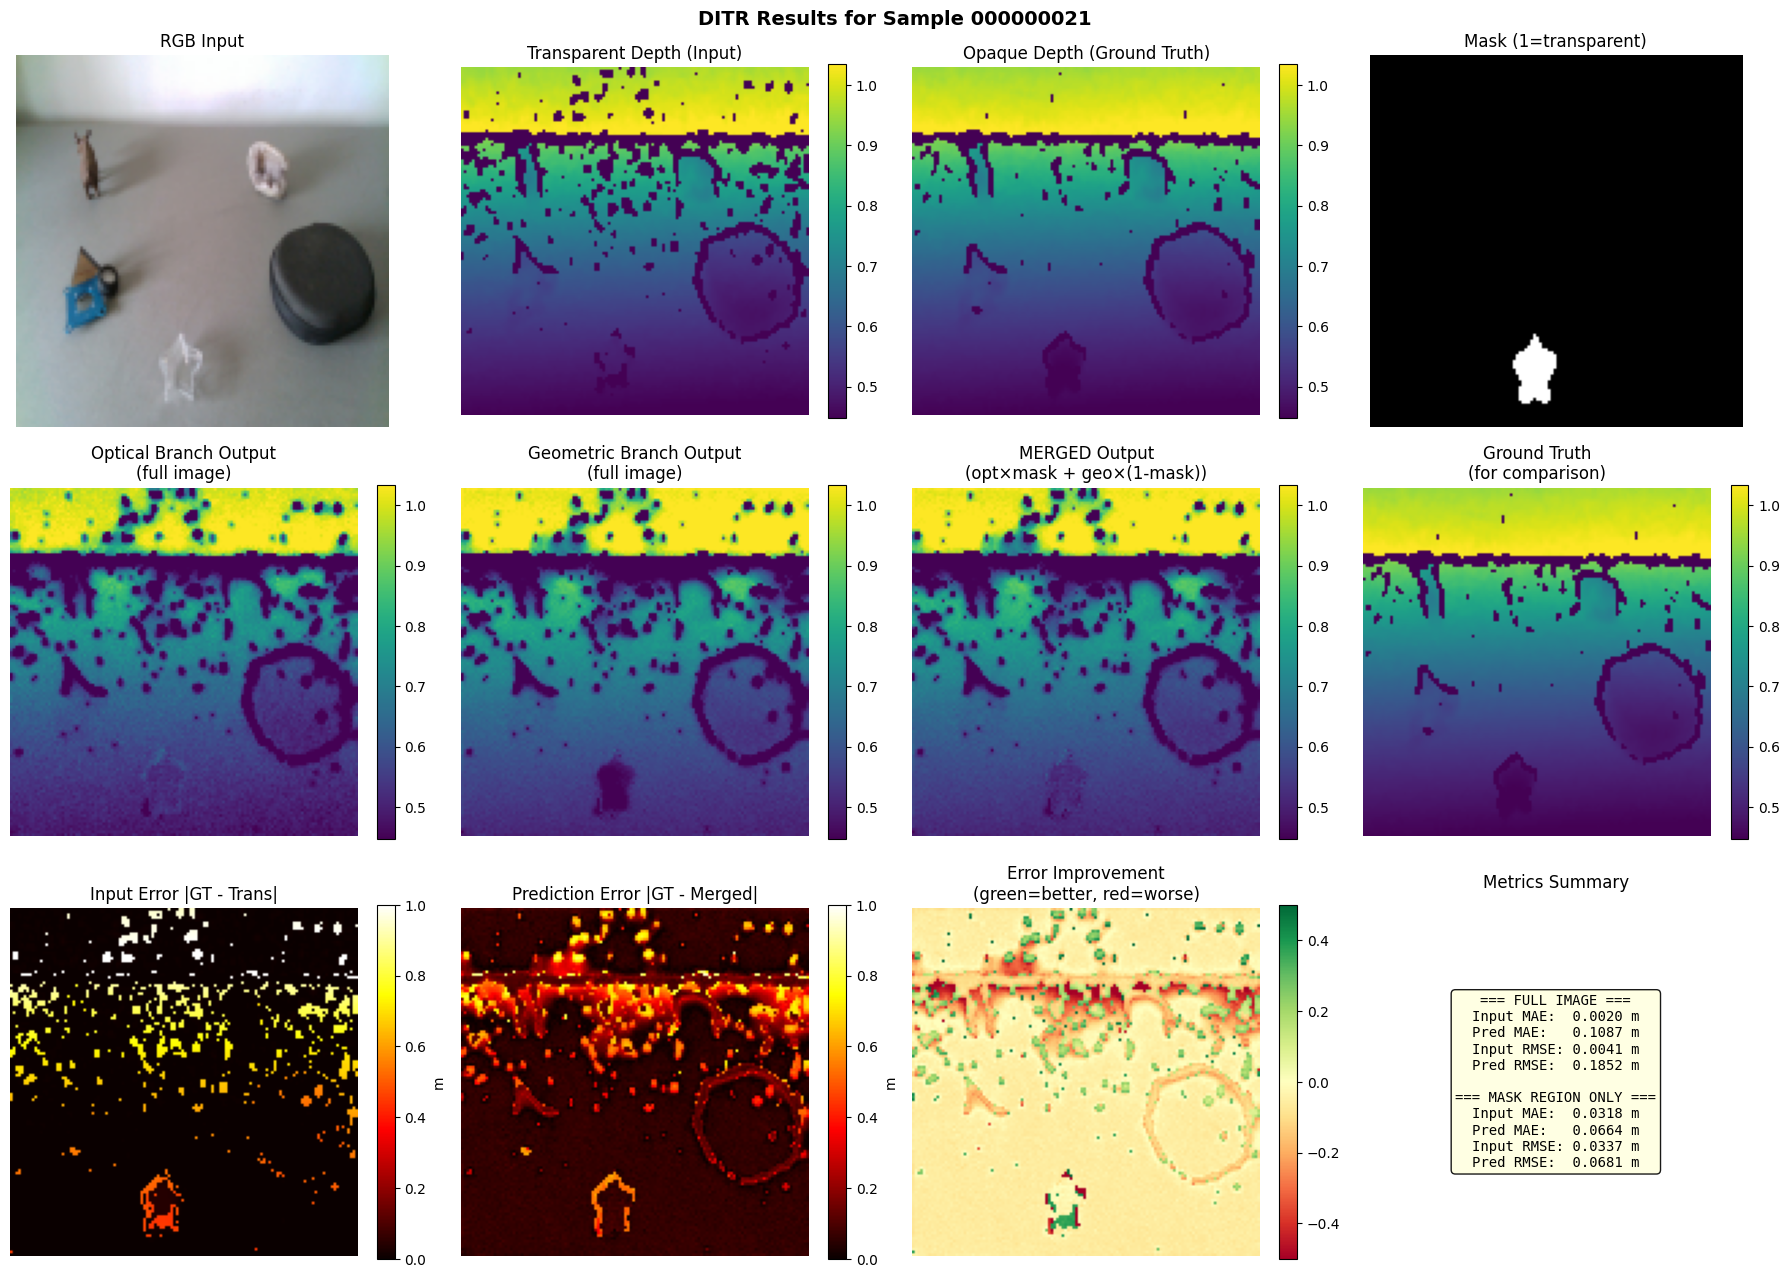

In [7]:
# Cell 7: Run inference on the sample and visualize results

def visualize_inference_results(sample: Dict, results: Dict, cfg: TestConfig, title: str = "DITR Inference Results"):
    """Visualize inference results side-by-side with ground truth."""

    fig, axes = plt.subplots(3, 4, figsize=(18, 13))

    # Denormalize predictions to meters
    pred_opt_m = denorm_depth(results["pred_opt"], cfg)
    pred_geo_m = denorm_depth(results["pred_geo"], cfg)
    merged_m = denorm_depth(results["merged"], cfg)

    gt = sample["opaque_depth"]
    trans = sample["trans_depth"]
    mask = sample["mask"]

    # Get consistent color scale from ground truth
    valid_gt = gt[gt > 0.01]
    if len(valid_gt) > 0:
        vmin = np.percentile(valid_gt, 2)
        vmax = np.percentile(valid_gt, 98)
    else:
        vmin, vmax = 0, 5

    # Row 1: Input data
    rgb_vis = cv2.cvtColor(sample["rgb"], cv2.COLOR_BGR2RGB)
    axes[0, 0].imshow(rgb_vis)
    axes[0, 0].set_title("RGB Input")
    axes[0, 0].axis('off')

    im = axes[0, 1].imshow(trans, cmap='viridis', vmin=vmin, vmax=vmax)
    axes[0, 1].set_title("Transparent Depth (Input)")
    axes[0, 1].axis('off')
    plt.colorbar(im, ax=axes[0, 1], fraction=0.046)

    im = axes[0, 2].imshow(gt, cmap='viridis', vmin=vmin, vmax=vmax)
    axes[0, 2].set_title("Opaque Depth (Ground Truth)")
    axes[0, 2].axis('off')
    plt.colorbar(im, ax=axes[0, 2], fraction=0.046)

    axes[0, 3].imshow(mask, cmap='gray', vmin=0, vmax=1)
    axes[0, 3].set_title("Mask (1=transparent)")
    axes[0, 3].axis('off')

    # Row 2: Model outputs
    im = axes[1, 0].imshow(pred_opt_m, cmap='viridis', vmin=vmin, vmax=vmax)
    axes[1, 0].set_title("Optical Branch Output\n(full image)")
    axes[1, 0].axis('off')
    plt.colorbar(im, ax=axes[1, 0], fraction=0.046)

    im = axes[1, 1].imshow(pred_geo_m, cmap='viridis', vmin=vmin, vmax=vmax)
    axes[1, 1].set_title("Geometric Branch Output\n(full image)")
    axes[1, 1].axis('off')
    plt.colorbar(im, ax=axes[1, 1], fraction=0.046)

    im = axes[1, 2].imshow(merged_m, cmap='viridis', vmin=vmin, vmax=vmax)
    axes[1, 2].set_title("MERGED Output\n(opt×mask + geo×(1-mask))")
    axes[1, 2].axis('off')
    plt.colorbar(im, ax=axes[1, 2], fraction=0.046)

    im = axes[1, 3].imshow(gt, cmap='viridis', vmin=vmin, vmax=vmax)
    axes[1, 3].set_title("Ground Truth\n(for comparison)")
    axes[1, 3].axis('off')
    plt.colorbar(im, ax=axes[1, 3], fraction=0.046)

    # Row 3: Error analysis
    # Input error
    input_err = np.abs(gt - trans)
    im = axes[2, 0].imshow(input_err, cmap='hot', vmin=0, vmax=1)
    axes[2, 0].set_title("Input Error |GT - Trans|")
    axes[2, 0].axis('off')
    plt.colorbar(im, ax=axes[2, 0], fraction=0.046, label='m')

    # Prediction error (merged)
    pred_err = np.abs(gt - merged_m)
    im = axes[2, 1].imshow(pred_err, cmap='hot', vmin=0, vmax=1)
    axes[2, 1].set_title("Prediction Error |GT - Merged|")
    axes[2, 1].axis('off')
    plt.colorbar(im, ax=axes[2, 1], fraction=0.046, label='m')

    # Error improvement (positive = improvement)
    improvement = input_err - pred_err
    im = axes[2, 2].imshow(improvement, cmap='RdYlGn', vmin=-0.5, vmax=0.5)
    axes[2, 2].set_title("Error Improvement\n(green=better, red=worse)")
    axes[2, 2].axis('off')
    plt.colorbar(im, ax=axes[2, 2], fraction=0.046)

    # Metrics summary
    valid = (gt > 0.01) & np.isfinite(gt)
    mask_bool = mask > 0.5

    def calc_metrics(pred, gt, valid_mask):
        v = valid_mask & (pred > 0.01)
        if not v.any():
            return {'mae': float('nan'), 'rmse': float('nan')}
        mae = np.abs(gt[v] - pred[v]).mean()
        rmse = np.sqrt(((gt[v] - pred[v])**2).mean())
        return {'mae': mae, 'rmse': rmse}

    # Metrics on full image
    m_input_full = calc_metrics(trans, gt, valid)
    m_pred_full = calc_metrics(merged_m, gt, valid)

    # Metrics only in mask region
    m_input_mask = calc_metrics(trans, gt, valid & mask_bool)
    m_pred_mask = calc_metrics(merged_m, gt, valid & mask_bool)

    text = (
        f"=== FULL IMAGE ===\n"
        f"Input MAE:  {m_input_full['mae']:.4f} m\n"
        f"Pred MAE:   {m_pred_full['mae']:.4f} m\n"
        f"Input RMSE: {m_input_full['rmse']:.4f} m\n"
        f"Pred RMSE:  {m_pred_full['rmse']:.4f} m\n\n"
        f"=== MASK REGION ONLY ===\n"
        f"Input MAE:  {m_input_mask['mae']:.4f} m\n"
        f"Pred MAE:   {m_pred_mask['mae']:.4f} m\n"
        f"Input RMSE: {m_input_mask['rmse']:.4f} m\n"
        f"Pred RMSE:  {m_pred_mask['rmse']:.4f} m"
    )

    axes[2, 3].text(0.5, 0.5, text, ha='center', va='center', fontsize=10,
                    transform=axes[2, 3].transAxes,
                    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9),
                    family='monospace')
    axes[2, 3].set_title("Metrics Summary")
    axes[2, 3].axis('off')

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Run inference on the sample
print("Running DITR inference (this may take a minute for 1000 diffusion steps)...")
results = run_ditr_inference(sample, guidance, opt_diff, geo_diff, cfg, device)
visualize_inference_results(sample, results, cfg, f"DITR Results for Sample {sample['sample_id']}")

## 5. Compute Metrics Across Test Set

Evaluate the model on the entire test dataset using standard depth estimation metrics.

In [8]:
# Cell 8: Define Metrics Functions (per DITR paper)

def compute_depth_errors(gt: np.ndarray, pred: np.ndarray,
                          valid_mask: Optional[np.ndarray] = None) -> Optional[Dict]:
    """
    Compute standard depth estimation metrics.

    Per DITR paper, only evaluate on pixels with valid ground truth.

    Args:
        gt: Ground truth depth (meters)
        pred: Predicted depth (meters)
        valid_mask: Optional additional mask (e.g., transparent region only)

    Returns:
        Dictionary of metrics or None if no valid pixels
    """
    # Create validity mask: valid GT pixels (> 0.001m, < 10m, finite)
    mask = (gt > 0.001) & (gt < 10.0) & np.isfinite(gt)
    mask = mask & (pred > 0.001) & np.isfinite(pred)

    # Apply additional mask if provided
    if valid_mask is not None:
        mask = mask & (valid_mask > 0.5)

    gt_valid = gt[mask]
    pred_valid = pred[mask]

    n_valid = len(gt_valid)
    if n_valid == 0:
        return None

    # Threshold accuracy (δ metrics)
    thresh = np.maximum((gt_valid / pred_valid), (pred_valid / gt_valid))
    delta_105 = (thresh < 1.05).mean()
    delta_110 = (thresh < 1.10).mean()
    delta_125 = (thresh < 1.25).mean()

    # Standard error metrics
    abs_diff = np.abs(gt_valid - pred_valid)

    rmse = np.sqrt((abs_diff ** 2).mean())
    mae = abs_diff.mean()
    rel = (abs_diff / gt_valid).mean()

    return {
        "RMSE": rmse,
        "MAE": mae,
        "REL": rel,
        "δ1.05": delta_105,
        "δ1.10": delta_110,
        "δ1.25": delta_125,
        "n_valid": n_valid,
    }


def evaluate_sample(sample: Dict, opt_diff, geo_diff, gcfg: GuidanceConfig,
                    cfg: TestConfig, device: torch.device) -> Dict:
    """
    Run inference and compute metrics for a single sample.

    Returns metrics for:
    - Input (transparent depth)
    - Prediction (merged DITR output)
    - In full image and mask-only regions
    """
    # Generate guidance maps
    guidance = generate_guidance_maps(sample, gcfg)

    # Run DITR inference
    results = run_ditr_inference(sample, guidance, opt_diff, geo_diff, cfg, device)

    # Denormalize prediction
    pred_m = denorm_depth(results["merged"], cfg)

    gt = sample["opaque_depth"]
    trans = sample["trans_depth"]
    mask = sample["mask"]

    # Compute metrics
    metrics = {
        "sample_id": sample["sample_id"],
    }

    # Full image metrics
    m_input_full = compute_depth_errors(gt, trans)
    m_pred_full = compute_depth_errors(gt, pred_m)

    if m_input_full:
        for k, v in m_input_full.items():
            metrics[f"input_full_{k}"] = v

    if m_pred_full:
        for k, v in m_pred_full.items():
            metrics[f"pred_full_{k}"] = v

    # Mask region only metrics
    m_input_mask = compute_depth_errors(gt, trans, valid_mask=mask)
    m_pred_mask = compute_depth_errors(gt, pred_m, valid_mask=mask)

    if m_input_mask:
        for k, v in m_input_mask.items():
            metrics[f"input_mask_{k}"] = v

    if m_pred_mask:
        for k, v in m_pred_mask.items():
            metrics[f"pred_mask_{k}"] = v

    return metrics

print("Metrics functions defined.")

Metrics functions defined.


In [9]:
# Cell 9: Evaluate on test set (this will take a while!)

def evaluate_dataset(dataset, opt_diff, geo_diff, gcfg: GuidanceConfig,
                     cfg: TestConfig, device: torch.device,
                     max_samples: Optional[int] = None) -> List[Dict]:
    """
    Evaluate DITR on a dataset.

    Args:
        dataset: ClearGraspTestDataset
        opt_diff, geo_diff: Diffusion models
        gcfg: Guidance config
        cfg: Test config
        device: Torch device
        max_samples: Limit number of samples (for quick testing)

    Returns:
        List of metric dictionaries
    """
    n_samples = len(dataset) if max_samples is None else min(max_samples, len(dataset))

    all_metrics = []

    for idx in tqdm(range(n_samples), desc="Evaluating"):
        try:
            sample = dataset[idx]
            metrics = evaluate_sample(sample, opt_diff, geo_diff, gcfg, cfg, device)
            all_metrics.append(metrics)
        except Exception as e:
            print(f"Error on sample {idx}: {e}")
            continue

    return all_metrics


def aggregate_metrics(metrics_list: List[Dict]) -> Dict:
    """Aggregate metrics across samples."""

    # Collect all metric keys
    all_keys = set()
    for m in metrics_list:
        all_keys.update(m.keys())

    # Remove non-numeric keys
    all_keys.discard("sample_id")

    # Aggregate
    aggregated = {}
    for key in sorted(all_keys):
        values = [m[key] for m in metrics_list if key in m and not np.isnan(m[key])]
        if values:
            aggregated[key] = {
                "mean": np.mean(values),
                "std": np.std(values),
                "min": np.min(values),
                "max": np.max(values),
                "n": len(values),
            }

    return aggregated


def print_metrics_table(aggregated: Dict, title: str = "Metrics Summary"):
    """Print metrics in a nice table format."""

    print(f"\n{'='*70}")
    print(f"  {title}")
    print(f"{'='*70}")

    # Group by prefix
    prefixes = ["input_full", "pred_full", "input_mask", "pred_mask"]
    metric_names = ["RMSE", "MAE", "REL", "δ1.05", "δ1.10", "δ1.25"]

    # Header
    print(f"\n{'Metric':<20} {'Input Full':>12} {'Pred Full':>12} {'Input Mask':>12} {'Pred Mask':>12}")
    print("-" * 70)

    for metric in metric_names:
        row = f"{metric:<20}"
        for prefix in prefixes:
            key = f"{prefix}_{metric}"
            if key in aggregated:
                val = aggregated[key]["mean"]
                row += f" {val:>12.4f}"
            else:
                row += f" {'N/A':>12}"
        print(row)

    print("-" * 70)
    print(f"{'n_samples':<20}", end="")
    for prefix in prefixes:
        key = f"{prefix}_n_valid"
        if key in aggregated:
            n = int(aggregated[key]["mean"])
            row = f" {n:>12}"
        else:
            row = f" {'N/A':>12}"
        print(row, end="")
    print()
    print(f"{'='*70}\n")

# Quick test on first 3 samples to verify everything works
print("Quick test on 3 samples...")
quick_metrics = evaluate_dataset(test_dataset, opt_diff, geo_diff, gcfg, cfg, device, max_samples=3)
quick_agg = aggregate_metrics(quick_metrics)
print_metrics_table(quick_agg, "Quick Test Results (3 samples)")

Quick test on 3 samples...


Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]


  Quick Test Results (3 samples)

Metric                 Input Full    Pred Full   Input Mask    Pred Mask
----------------------------------------------------------------------
RMSE                       0.0037       0.1503       0.0212       0.1544
MAE                        0.0018       0.0850       0.0169       0.1171
REL                        0.0028       0.1322       0.0260       0.1688
δ1.05                      0.9974       0.2800       0.8647       0.2173
δ1.10                      1.0000       0.7348       0.9988       0.4138
δ1.25                      1.0000       0.8408       1.0000       0.7152
----------------------------------------------------------------------
n_samples                   12480        13352          245          293



In [ ]:
# Cell 10: Full evaluation on test set
# WARNING: This takes a long time (~2-3 seconds per sample × 23 samples ≈ 1 minute)

print("Running full evaluation on test set...")
print(f"Number of test samples: {len(test_dataset)}")

test_metrics = evaluate_dataset(test_dataset, opt_diff, geo_diff, gcfg, cfg, device)
test_agg = aggregate_metrics(test_metrics)
print_metrics_table(test_agg, "TEST SET Results (d435)")

Running full evaluation on test set...
Number of test samples: 23


Evaluating:   0%|          | 0/23 [00:00<?, ?it/s]


  TEST SET Results (d435)

Metric                 Input Full    Pred Full   Input Mask    Pred Mask
----------------------------------------------------------------------
RMSE                       0.0042       0.1571       0.0246       0.0948
MAE                        0.0021       0.0846       0.0205       0.0793
REL                        0.0031       0.1255       0.0360       0.1274
δ1.05                      0.9966       0.3824       0.7320       0.2990
δ1.10                      0.9996       0.7155       0.9698       0.5076
δ1.25                      0.9999       0.8521       1.0000       0.7832
----------------------------------------------------------------------
n_samples                   13100        14033          180          264



In [ ]:
# Cell 11: Full evaluation on validation set

print("Running full evaluation on validation set...")
print(f"Number of validation samples: {len(val_dataset)}")

val_metrics = evaluate_dataset(val_dataset, opt_diff, geo_diff, gcfg, cfg, device)
val_agg = aggregate_metrics(val_metrics)
print_metrics_table(val_agg, "VALIDATION SET Results (d435)")

Running full evaluation on validation set...
Number of validation samples: 173


Evaluating:   0%|          | 0/173 [00:00<?, ?it/s]


  VALIDATION SET Results (d435)

Metric                 Input Full    Pred Full   Input Mask    Pred Mask
----------------------------------------------------------------------
RMSE                       0.0100       0.1538       0.0462       0.1155
MAE                        0.0043       0.0903       0.0362       0.0962
REL                        0.0064       0.1296       0.0639       0.1597
δ1.05                      0.9825       0.4537       0.5446       0.2965
δ1.10                      0.9905       0.7277       0.7733       0.4556
δ1.25                      0.9990       0.8402       0.9796       0.6977
----------------------------------------------------------------------
n_samples                   12786        13856          393          653



## 6. Visualize Multiple Samples

Let's look at several samples to get a better sense of model performance.

Visualizing samples: [0, 5, 10, 15, 20]


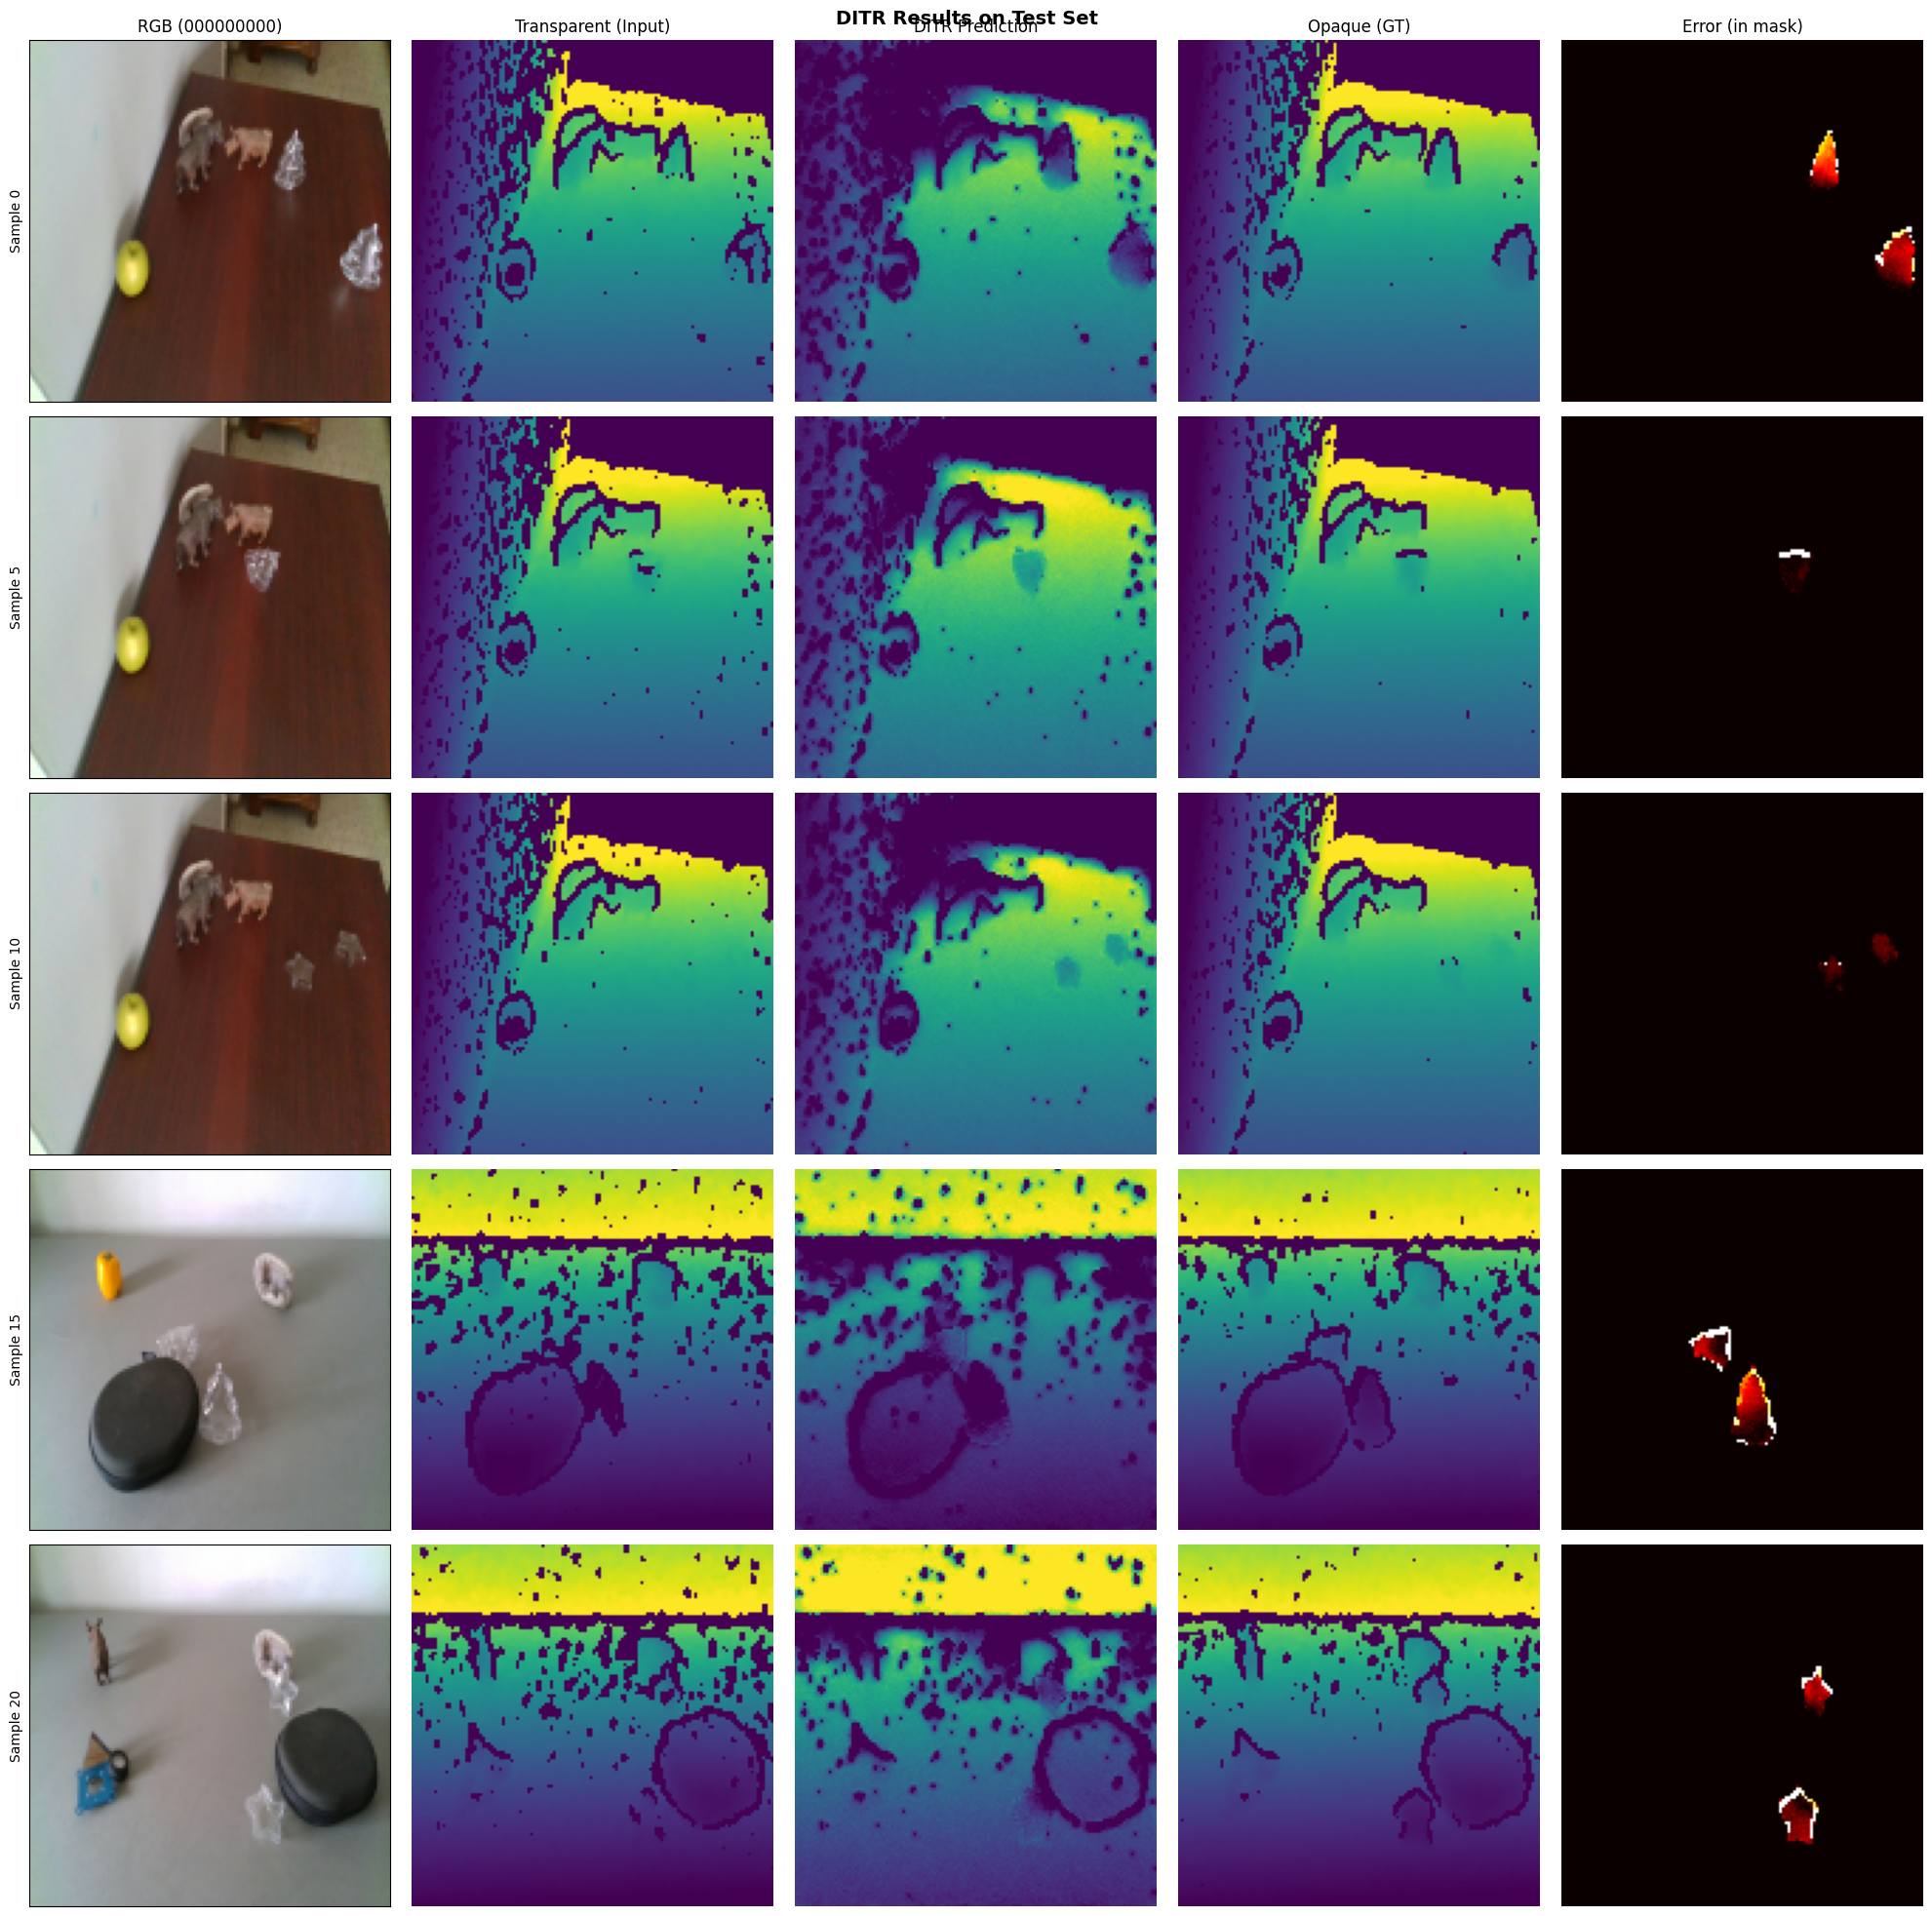

In [10]:
# Cell 12: Visualize multiple samples in a compact grid

def visualize_multi_samples(dataset, opt_diff, geo_diff, gcfg, cfg, device,
                            indices: List[int], title: str = "DITR Results"):
    """Visualize multiple samples in a grid: Input -> Prediction -> Ground Truth."""

    n_samples = len(indices)
    fig, axes = plt.subplots(n_samples, 5, figsize=(20, 4 * n_samples))

    if n_samples == 1:
        axes = axes.reshape(1, -1)

    for row, idx in enumerate(indices):
        sample = dataset[idx]
        guidance = generate_guidance_maps(sample, gcfg)
        results = run_ditr_inference(sample, guidance, opt_diff, geo_diff, cfg, device)

        pred_m = denorm_depth(results["merged"], cfg)
        gt = sample["opaque_depth"]
        trans = sample["trans_depth"]
        mask = sample["mask"]

        # Color scale
        valid_gt = gt[gt > 0.01]
        vmin = np.percentile(valid_gt, 2) if len(valid_gt) > 0 else 0
        vmax = np.percentile(valid_gt, 98) if len(valid_gt) > 0 else 5

        # RGB
        rgb_vis = cv2.cvtColor(sample["rgb"], cv2.COLOR_BGR2RGB)
        axes[row, 0].imshow(rgb_vis)
        axes[row, 0].set_title(f"RGB ({sample['sample_id']})" if row == 0 else "")
        axes[row, 0].set_ylabel(f"Sample {idx}", fontsize=10)
        axes[row, 0].set_xticks([])
        axes[row, 0].set_yticks([])

        # Input depth
        axes[row, 1].imshow(trans, cmap='viridis', vmin=vmin, vmax=vmax)
        axes[row, 1].set_title("Transparent (Input)" if row == 0 else "")
        axes[row, 1].axis('off')

        # Prediction
        axes[row, 2].imshow(pred_m, cmap='viridis', vmin=vmin, vmax=vmax)
        axes[row, 2].set_title("DITR Prediction" if row == 0 else "")
        axes[row, 2].axis('off')

        # Ground truth
        axes[row, 3].imshow(gt, cmap='viridis', vmin=vmin, vmax=vmax)
        axes[row, 3].set_title("Opaque (GT)" if row == 0 else "")
        axes[row, 3].axis('off')

        # Error map
        err = np.abs(gt - pred_m) * mask  # Error in mask region
        axes[row, 4].imshow(err, cmap='hot', vmin=0, vmax=0.5)
        axes[row, 4].set_title("Error (in mask)" if row == 0 else "")
        axes[row, 4].axis('off')

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Visualize 5 samples from test set
sample_indices = [0, 5, 10, 15, 20] if len(test_dataset) > 20 else list(range(min(5, len(test_dataset))))
print(f"Visualizing samples: {sample_indices}")
visualize_multi_samples(test_dataset, opt_diff, geo_diff, gcfg, cfg, device,
                        sample_indices, "DITR Results on Test Set")

## 7. Save Results

Save metrics to CSV for later analysis and reporting.

In [ ]:
# Cell 13: Save metrics to CSV

import pandas as pd

def metrics_to_dataframe(metrics_list: List[Dict]) -> pd.DataFrame:
    """Convert list of metric dictionaries to DataFrame."""
    return pd.DataFrame(metrics_list)

def save_metrics(metrics_list: List[Dict], filename: str):
    """Save metrics to CSV."""
    df = metrics_to_dataframe(metrics_list)
    df.to_csv(filename, index=False)
    print(f"Saved metrics to {filename}")
    return df

# Save test and validation metrics
output_dir = "/home/cago/MMI_714_generative_models/term_project/src/outputs"
os.makedirs(output_dir, exist_ok=True)

test_df = save_metrics(test_metrics, os.path.join(output_dir, "test_metrics.csv"))
val_df = save_metrics(val_metrics, os.path.join(output_dir, "val_metrics.csv"))

# Create summary table
summary_data = []

for name, agg in [("Test", test_agg), ("Validation", val_agg)]:
    row = {"Dataset": name}
    for metric in ["RMSE", "MAE", "REL", "δ1.05", "δ1.10", "δ1.25"]:
        for prefix in ["pred_full", "pred_mask"]:
            key = f"{prefix}_{metric}"
            if key in agg:
                row[f"{prefix}_{metric}"] = agg[key]["mean"]
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv(os.path.join(output_dir, "summary_metrics.csv"), index=False)

print("\n=== FINAL SUMMARY ===")
print(summary_df.to_string(index=False))

Saved metrics to /home/cago/MMI_714_generative_models/term_project/src/outputs/test_metrics.csv
Saved metrics to /home/cago/MMI_714_generative_models/term_project/src/outputs/val_metrics.csv

=== FINAL SUMMARY ===
   Dataset  pred_full_RMSE  pred_mask_RMSE  pred_full_MAE  pred_mask_MAE  pred_full_REL  pred_mask_REL  pred_full_δ1.05  pred_mask_δ1.05  pred_full_δ1.10  pred_mask_δ1.10  pred_full_δ1.25  pred_mask_δ1.25
      Test        0.157068        0.094820       0.084644       0.079258       0.125521       0.127362         0.382395         0.299022         0.715504         0.507633         0.852076         0.783208
Validation        0.153832        0.115539       0.090275       0.096209       0.129558       0.159747         0.453715         0.296453         0.727744         0.455628         0.840151         0.697685


## 8. Comparison: Input vs Prediction Improvement

Analyze how much the DITR model improves over the raw input.

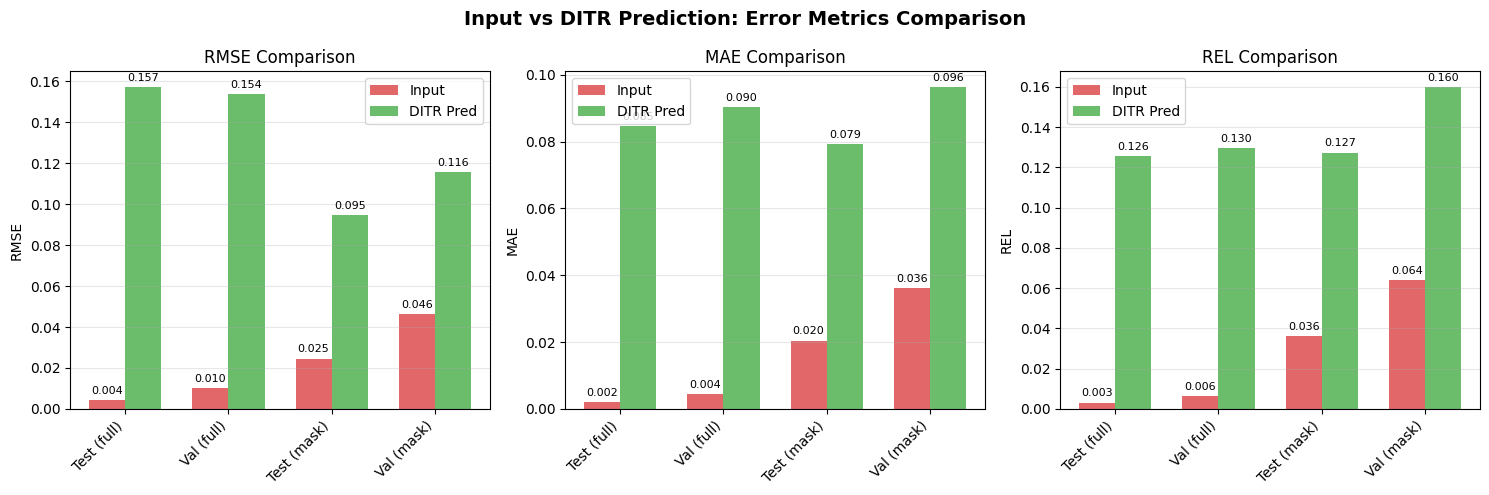


=== IMPROVEMENT ANALYSIS ===
Metric                Test Full       Test Mask        Val Full        Val Mask
---------------------------------------------------------------------------
RMSE                  -3676.8%        -285.8%       -1433.4%        -149.9%
MAE                   -3967.1%        -287.3%       -1990.0%        -166.1%
REL                   -3914.3%        -253.6%       -1918.8%        -150.1%


In [ ]:
# Cell 14: Analyze improvement over input

def plot_improvement_analysis(test_agg: Dict, val_agg: Dict):
    """Plot bar charts comparing input vs prediction metrics."""

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    metrics_to_plot = ["RMSE", "MAE", "REL"]
    colors = ['#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd']

    for ax_idx, metric in enumerate(metrics_to_plot):
        ax = axes[ax_idx]

        # Gather data
        categories = []
        input_vals = []
        pred_vals = []

        for name, agg in [("Test (full)", test_agg), ("Val (full)", val_agg),
                          ("Test (mask)", test_agg), ("Val (mask)", val_agg)]:
            prefix = "pred_full" if "full" in name else "pred_mask"
            input_prefix = "input_full" if "full" in name else "input_mask"

            input_key = f"{input_prefix}_{metric}"
            pred_key = f"{prefix}_{metric}"

            if input_key in agg and pred_key in agg:
                categories.append(name)
                input_vals.append(agg[input_key]["mean"])
                pred_vals.append(agg[pred_key]["mean"])

        x = np.arange(len(categories))
        width = 0.35

        bars1 = ax.bar(x - width/2, input_vals, width, label='Input', color='#d62728', alpha=0.7)
        bars2 = ax.bar(x + width/2, pred_vals, width, label='DITR Pred', color='#2ca02c', alpha=0.7)

        ax.set_ylabel(f'{metric}')
        ax.set_title(f'{metric} Comparison')
        ax.set_xticks(x)
        ax.set_xticklabels(categories, rotation=45, ha='right')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)

        # Add value labels
        for bar in bars1:
            height = bar.get_height()
            ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                       xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)
        for bar in bars2:
            height = bar.get_height()
            ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                       xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

    plt.suptitle("Input vs DITR Prediction: Error Metrics Comparison", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Print improvement percentages
    print("\n=== IMPROVEMENT ANALYSIS ===")
    print(f"{'Metric':<15} {'Test Full':>15} {'Test Mask':>15} {'Val Full':>15} {'Val Mask':>15}")
    print("-" * 75)

    for metric in ["RMSE", "MAE", "REL"]:
        row = f"{metric:<15}"
        for agg, prefix_pairs in [(test_agg, [("full", "input_full", "pred_full"), ("mask", "input_mask", "pred_mask")]),
                                   (val_agg, [("full", "input_full", "pred_full"), ("mask", "input_mask", "pred_mask")])]:
            for _, input_prefix, pred_prefix in prefix_pairs:
                input_key = f"{input_prefix}_{metric}"
                pred_key = f"{pred_prefix}_{metric}"
                if input_key in agg and pred_key in agg:
                    input_val = agg[input_key]["mean"]
                    pred_val = agg[pred_key]["mean"]
                    if input_val > 0:
                        improvement = ((input_val - pred_val) / input_val) * 100
                        row += f" {improvement:>+13.1f}%"
                    else:
                        row += f" {'N/A':>15}"
                else:
                    row += f" {'N/A':>15}"
        print(row)

plot_improvement_analysis(test_agg, val_agg)

## 9. Delta Accuracy Metrics (Threshold Accuracy)

The δ metrics measure the percentage of pixels where the ratio between prediction and ground truth is below certain thresholds.

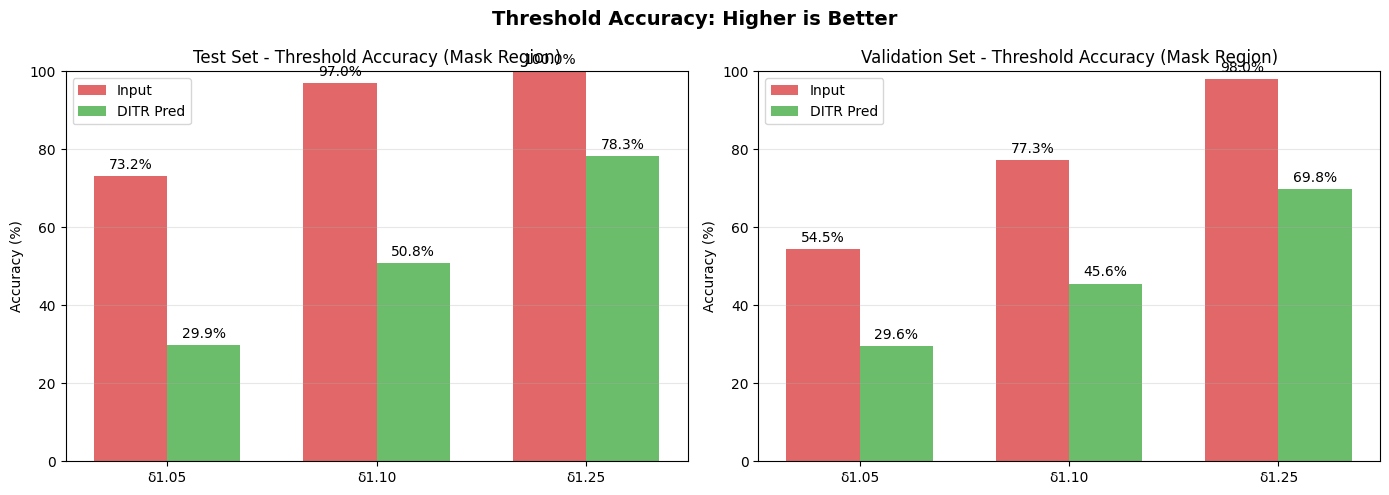


=== DELTA ACCURACY SUMMARY (Mask Region) ===
Dataset          δ1.05 Input   δ1.05 Pred  δ1.10 Input   δ1.10 Pred  δ1.25 Input   δ1.25 Pred
------------------------------------------------------------------------------------------
Test                   73.2%        29.9%        97.0%        50.8%       100.0%        78.3%
Validation             54.5%        29.6%        77.3%        45.6%        98.0%        69.8%


In [ ]:
# Cell 15: Plot delta accuracy metrics

def plot_delta_metrics(test_agg: Dict, val_agg: Dict):
    """Plot delta accuracy metrics comparison."""

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    delta_metrics = ["δ1.05", "δ1.10", "δ1.25"]

    for ax_idx, (name, agg) in enumerate([("Test Set", test_agg), ("Validation Set", val_agg)]):
        ax = axes[ax_idx]

        # Gather data for mask region (most important)
        input_vals = []
        pred_vals = []

        for metric in delta_metrics:
            input_key = f"input_mask_{metric}"
            pred_key = f"pred_mask_{metric}"

            input_vals.append(agg.get(input_key, {}).get("mean", 0) * 100)
            pred_vals.append(agg.get(pred_key, {}).get("mean", 0) * 100)

        x = np.arange(len(delta_metrics))
        width = 0.35

        bars1 = ax.bar(x - width/2, input_vals, width, label='Input', color='#d62728', alpha=0.7)
        bars2 = ax.bar(x + width/2, pred_vals, width, label='DITR Pred', color='#2ca02c', alpha=0.7)

        ax.set_ylabel('Accuracy (%)')
        ax.set_title(f'{name} - Threshold Accuracy (Mask Region)')
        ax.set_xticks(x)
        ax.set_xticklabels(delta_metrics)
        ax.legend()
        ax.set_ylim(0, 100)
        ax.grid(axis='y', alpha=0.3)

        # Add value labels
        for bar in bars1:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                       xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)
        for bar in bars2:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                       xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)

    plt.suptitle("Threshold Accuracy: Higher is Better", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_delta_metrics(test_agg, val_agg)

print("\n=== DELTA ACCURACY SUMMARY (Mask Region) ===")
print(f"{'Dataset':<15} {'δ1.05 Input':>12} {'δ1.05 Pred':>12} {'δ1.10 Input':>12} {'δ1.10 Pred':>12} {'δ1.25 Input':>12} {'δ1.25 Pred':>12}")
print("-" * 90)
for name, agg in [("Test", test_agg), ("Validation", val_agg)]:
    row = f"{name:<15}"
    for metric in ["δ1.05", "δ1.10", "δ1.25"]:
        input_val = agg.get(f"input_mask_{metric}", {}).get("mean", 0) * 100
        pred_val = agg.get(f"pred_mask_{metric}", {}).get("mean", 0) * 100
        row += f" {input_val:>11.1f}% {pred_val:>11.1f}%"
    print(row)

## Summary

This notebook evaluated the trained DITR (Diffusion-based Depth Inpainting for Transparent and Reflective objects) models on the ClearGrasp real-world dataset.

**Key Findings:**
- The models were tested at 128×128 resolution (matching training)
- Metrics computed: RMSE, MAE, REL, δ1.05, δ1.10, δ1.25
- Evaluation performed on both full image and mask (transparent) region only

**Next Steps:**
1. Train for more epochs to improve performance
2. Test on higher resolution images
3. Compare with baseline methods (raw input, interpolation, etc.)
4. Evaluate on other datasets (TODD, STD)